In [1]:
"""
1D Hydrogen Transport Model: CLLiF (liquid) | Inconel (solid)
==============================================================

Geometry (x-axis):
    [0, L_liquid]                : CLLiF melt  (x = 0 → liquid top surface)
    [L_liquid, L_liquid+L_solid] : Inconel 625 (x = L_liquid+L_solid → solid bottom)

Boundary conditions:
    x = 0          : c = 0  (tritium released to gap / free surface)
    x = L_liquid   : discontinuous interface (CLLiF <-> Inconel)
    x = L_liquid + L_solid : selectable via right_bc argument:
                     "zero_flux"     — default Neumann (no action)
                     "dirichlet"     — fixed c = 0
                     "recomb_he"     — J = -Kr * c²
                     "recomb_h2"     — J = -Kr * c² - Kr * c_H2 * c
                     "recomb_large"  — Kr x 1e48
"""

import numpy as np
import festim as F
import h_transport_materials as htm
import requests
import ufl
from dolfinx import fem
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Geometry
# ---------------------------------------------------------------------------
L_liquid = 0.07
L_solid = 0.003

ID_LIQUID = 1
ID_SOLID = 2
ID_LEFT = 1
ID_IFACE = 2
ID_RIGHT = 3

# ---------------------------------------------------------------------------
# Material properties
# ---------------------------------------------------------------------------
Na = 6.022e23

htm_D_flibe = htm.diffusivities.filter(material="flibe").filter(author="calderoni")
htm_S_flibe = htm.solubilities.filter(material="flibe").filter(author="calderoni")
htm_D_inconel = htm.diffusivities.filter(material="inconel_625")
htm_S_inconel = htm.solubilities.filter(material="inconel_625")
htm_Kr_inconel = htm.recombination_coeffs.filter(material="inconel_625")

flibe_D_0 = htm_D_flibe[0].pre_exp.magnitude
flibe_E_D = htm_D_flibe[0].act_energy.magnitude
flibe_S_0 = htm_S_flibe[0].pre_exp.magnitude
flibe_E_S = htm_S_flibe[0].act_energy.magnitude

inconel_D_0 = htm_D_inconel[0].pre_exp.magnitude
inconel_E_D = htm_D_inconel[0].act_energy.magnitude
inconel_S_0 = htm_S_inconel[0].pre_exp.magnitude
inconel_E_S = htm_S_inconel[0].act_energy.magnitude
inconel_Kr_0 = htm_Kr_inconel[1].pre_exp.magnitude
inconel_E_Kr = htm_Kr_inconel[1].act_energy.magnitude

# ---------------------------------------------------------------------------
# Temperature
# ---------------------------------------------------------------------------
temperature_K = 650 + 273.15

D_fl = flibe_D_0 * np.exp(-flibe_E_D / (F.k_B * temperature_K))
K_fl = flibe_S_0 * np.exp(-flibe_E_S / (F.k_B * temperature_K))
D_in = inconel_D_0 * np.exp(-inconel_E_D / (F.k_B * temperature_K))
K_in = inconel_S_0 * np.exp(-inconel_E_S / (F.k_B * temperature_K))
Kr_val = inconel_Kr_0 * np.exp(-inconel_E_Kr / (F.k_B * temperature_K))

# ---------------------------------------------------------------------------
# Penalty
# ---------------------------------------------------------------------------
penalty = 1e35
atol = 1e4
rtol = 1e-10

# ---------------------------------------------------------------------------
# H2 sweep gas concentration
# ---------------------------------------------------------------------------
h2_P_gauge = 3
h2_conc_ppm = 1000
P_atm = 14.7
P_h2 = (h2_conc_ppm / 1e6) * (h2_P_gauge + P_atm) * 6894.76
h2_conc = (P_h2 / (8.314 * 298)) * Na


# ---------------------------------------------------------------------------
# Irradiation time
# ---------------------------------------------------------------------------
def get_total_irradiation_time() -> float:
    from libra_toolbox.tritium.model import ureg

    url = "https://raw.githubusercontent.com/LIBRA-project/BABY-1L-run-1/refs/tags/v0.5/data/processed_data.json"
    data = requests.get(url).json()
    duration = 0.0
    for irr in data["irradiations"]:
        start = irr["start_time"]["value"] * ureg(irr["start_time"]["unit"])
        end = irr["stop_time"]["value"] * ureg(irr["stop_time"]["unit"])
        duration += (end - start).to(ureg("s")).magnitude
    return duration


irradiation_time = get_total_irradiation_time()


def tritium_source(t):
    return 2.19e8 if t < irradiation_time else 0.0


# ---------------------------------------------------------------------------
# Recombination flux functions
# ---------------------------------------------------------------------------
def recomb_he(c, T):
    Kr = inconel_Kr_0 * ufl.exp(-inconel_E_Kr / (F.k_B * T))
    return -Kr * c**2


def recomb_h2(c, T):
    Kr = inconel_Kr_0 * ufl.exp(-inconel_E_Kr / (F.k_B * T))
    return -Kr * c**2 - Kr * h2_conc * c


def recomb_large(c, T):
    Kr = inconel_Kr_0 * 1e48 * ufl.exp(-inconel_E_Kr / (F.k_B * T))
    return -Kr * c**2


# ---------------------------------------------------------------------------
# Custom recomb-eq flux export — like the 2D version, computes
#     J = (Kr * c^2 + Kr * c_H2 * c)   [H/m^2/s]
# directly from the FE solution at the surface, without referencing
# any analytical c value.
# ---------------------------------------------------------------------------
class RecombFluxExport(F.SurfaceFlux):
    """Compute Kr * c^2 (+ Kr * c_H2 * c) on a 1D surface, evaluated by FESTIM."""

    def __init__(
        self,
        field,
        surface,
        filename,
        volume_subdomain,
        Kr_0,
        E_Kr,
        temperature,
        h2_conc=0.0,
        kr_multiplier=1.0,
    ):
        super().__init__(field=field, surface=surface, filename=filename)
        self.volume_subdomain = volume_subdomain
        self.Kr_0 = Kr_0
        self.E_Kr = E_Kr
        self.temperature = temperature
        self.h2_conc = h2_conc
        self.kr_multiplier = kr_multiplier

    def compute(self, u, ds, entity_maps):
        from scifem import assemble_scalar

        Kr = (
            self.kr_multiplier
            * self.Kr_0
            * ufl.exp(-self.E_Kr / (F.k_B * self.temperature))
        )

        # Physical release: T+T -> T2, plus T+H -> HT (if H2 present)
        integrand = Kr * u**2 + Kr * self.h2_conc * u

        flux = assemble_scalar(
            fem.form(
                integrand * ds(self.surface.id),
                entity_maps=entity_maps,
            )
        )
        self.value = flux
        self.data.append(self.value)


# ---------------------------------------------------------------------------
# Build model
# ---------------------------------------------------------------------------
def build_model(right_bc: str = "recomb_he", final_time: float = 1e5):
    model = F.HydrogenTransportProblemDiscontinuous()

    vertices = np.unique(
        np.concatenate(
            [
                np.linspace(0, L_liquid, 200),
                np.linspace(L_liquid, L_liquid + L_solid, 50),
            ]
        )
    )
    model.mesh = F.Mesh1D(vertices)

    mat_cllif = F.Material(
        D_0=flibe_D_0,
        E_D=flibe_E_D,
        K_S_0=flibe_S_0,
        E_K_S=flibe_E_S,
        solubility_law="henry",
    )
    mat_inconel = F.Material(
        D_0=inconel_D_0,
        E_D=inconel_E_D,
        K_S_0=inconel_S_0,
        E_K_S=inconel_E_S,
        solubility_law="sievert",
    )

    vol_cllif = F.VolumeSubdomain1D(
        id=ID_LIQUID, borders=[0, L_liquid], material=mat_cllif
    )
    vol_inconel = F.VolumeSubdomain1D(
        id=ID_SOLID, borders=[L_liquid, L_liquid + L_solid], material=mat_inconel
    )
    surf_left = F.SurfaceSubdomain1D(id=ID_LEFT, x=0.0)
    surf_right = F.SurfaceSubdomain1D(id=ID_RIGHT, x=L_liquid + L_solid)

    iface = F.Interface(
        id=ID_IFACE, subdomains=[vol_cllif, vol_inconel], penalty_term=penalty
    )

    model.subdomains = [vol_cllif, vol_inconel, surf_left, surf_right]
    model.interfaces = [iface]
    model.surface_to_volume = {surf_left: vol_cllif, surf_right: vol_inconel}

    T_sp = F.Species("T", mobile=True, subdomains=[vol_cllif, vol_inconel])
    model.species = [T_sp]

    model.sources = [
        F.ParticleSource(value=tritium_source, volume=vol_cllif, species=T_sp)
    ]

    bc_list = [F.FixedConcentrationBC(subdomain=surf_left, species=T_sp, value=0.0)]

    flux_fn_map = {
        "recomb_he": recomb_he,
        "recomb_h2": recomb_h2,
        "recomb_large": recomb_large,
    }

    if right_bc == "zero_flux":
        pass
    elif right_bc == "dirichlet":
        bc_list.append(
            F.FixedConcentrationBC(subdomain=surf_right, species=T_sp, value=0.0)
        )
    elif right_bc in flux_fn_map:
        bc_list.append(
            F.ParticleFluxBC(
                value=flux_fn_map[right_bc],
                subdomain=surf_right,
                species_dependent_value={"c": T_sp},
                species=T_sp,
            )
        )
    else:
        raise ValueError(f"Unknown right_bc='{right_bc}'.")

    model.boundary_conditions = bc_list
    model.temperature = temperature_K

    model.settings = F.Settings(
        transient=True,
        atol=atol,
        rtol=rtol,
        final_time=final_time,
        stepsize=F.Stepsize(
            initial_value=10,
            growth_factor=1.1,
            cutback_factor=0.9,
            target_nb_iterations=4,
            milestones=[irradiation_time],
        ),
    )

    # Match the recomb-eq export to whatever Kr the BC actually uses.
    if right_bc == "recomb_h2":
        h2_for_export = h2_conc
        kr_mult = 1.0
    elif right_bc == "recomb_large":
        h2_for_export = 0.0
        kr_mult = 1e48
    else:
        # zero_flux / dirichlet / recomb_he : standard Kr, no H2
        h2_for_export = 0.0
        kr_mult = 1.0

    os.makedirs(f"results_1d/{right_bc}", exist_ok=True)
    model.exports = [
        F.VTXSpeciesExport(
            filename=f"results_1d/{right_bc}/T_cllif.bp",
            field=T_sp,
            subdomain=vol_cllif,
        ),
        F.VTXSpeciesExport(
            filename=f"results_1d/{right_bc}/T_inconel.bp",
            field=T_sp,
            subdomain=vol_inconel,
        ),
        F.TotalVolume(
            field=T_sp,
            volume=vol_cllif,
            filename=f"results_1d/{right_bc}/inventory_cllif.csv",
        ),
        F.TotalVolume(
            field=T_sp,
            volume=vol_inconel,
            filename=f"results_1d/{right_bc}/inventory_inconel.csv",
        ),
        # FESTIM native: -D grad(c) . n at the right surface
        F.SurfaceFlux(
            field=T_sp,
            surface=surf_right,
            filename=f"results_1d/{right_bc}/flux_outer_wall.csv",
        ),
        # Recomb-eq flux: directly evaluate Kr*c^2 (+ Kr*c_H2*c) on the boundary
        RecombFluxExport(
            field=T_sp,
            surface=surf_right,
            filename=f"results_1d/{right_bc}/flux_outer_wall_recomb_eq.csv",
            volume_subdomain=vol_inconel,
            Kr_0=inconel_Kr_0,
            E_Kr=inconel_E_Kr,
            temperature=temperature_K,
            h2_conc=h2_for_export,
            kr_multiplier=kr_mult,
        ),
    ]

    return model, T_sp, vol_cllif, vol_inconel


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    cases = ["zero_flux", "dirichlet", "recomb_he", "recomb_h2", "recomb_large"]

    for case in cases:
        print(f"\n{'=' * 60}")
        print(f"  Running case: {case}")
        print(f"{'=' * 60}")

        model, T_sp, vol_cllif, vol_inconel = build_model(right_bc=case, final_time=1e5)
        model.initialise()
        model.run()

        del model
        gc.collect()



/home/huihuay/anaconda3/envs/baby-tritium-transport-env/lib/python3.13/site-packages/festim/coupled_heat_hydrogen_problem.py:1: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  import tqdm.autonotebook
/home/huihuay/anaconda3/envs/baby-tritium-transport-env/lib/python3.13/site-packages/pybtex/plugin/__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



  Running case: zero_flux


Solving HydrogenTransportProblemDiscontinuous: 100%|██████████| 100k/100k [00:15<00:00, 6.46kit/s] 



  Running case: dirichlet


Solving HydrogenTransportProblemDiscontinuous: 100%|██████████| 100k/100k [00:15<00:00, 6.25kit/s] 


...

Solving HydrogenTransportProblemDiscontinuous: 100%|██████████| 100k/100k [00:15<00:00, 6.63kit/s] 



  Running case: recomb_h2


Solving HydrogenTransportProblemDiscontinuous: 100%|██████████| 100k/100k [00:15<00:00, 6.42kit/s] 



  Running case: recomb_large


Solving HydrogenTransportProblemDiscontinuous: 100%|██████████| 100k/100k [00:19<00:00, 5.26kit/s] 


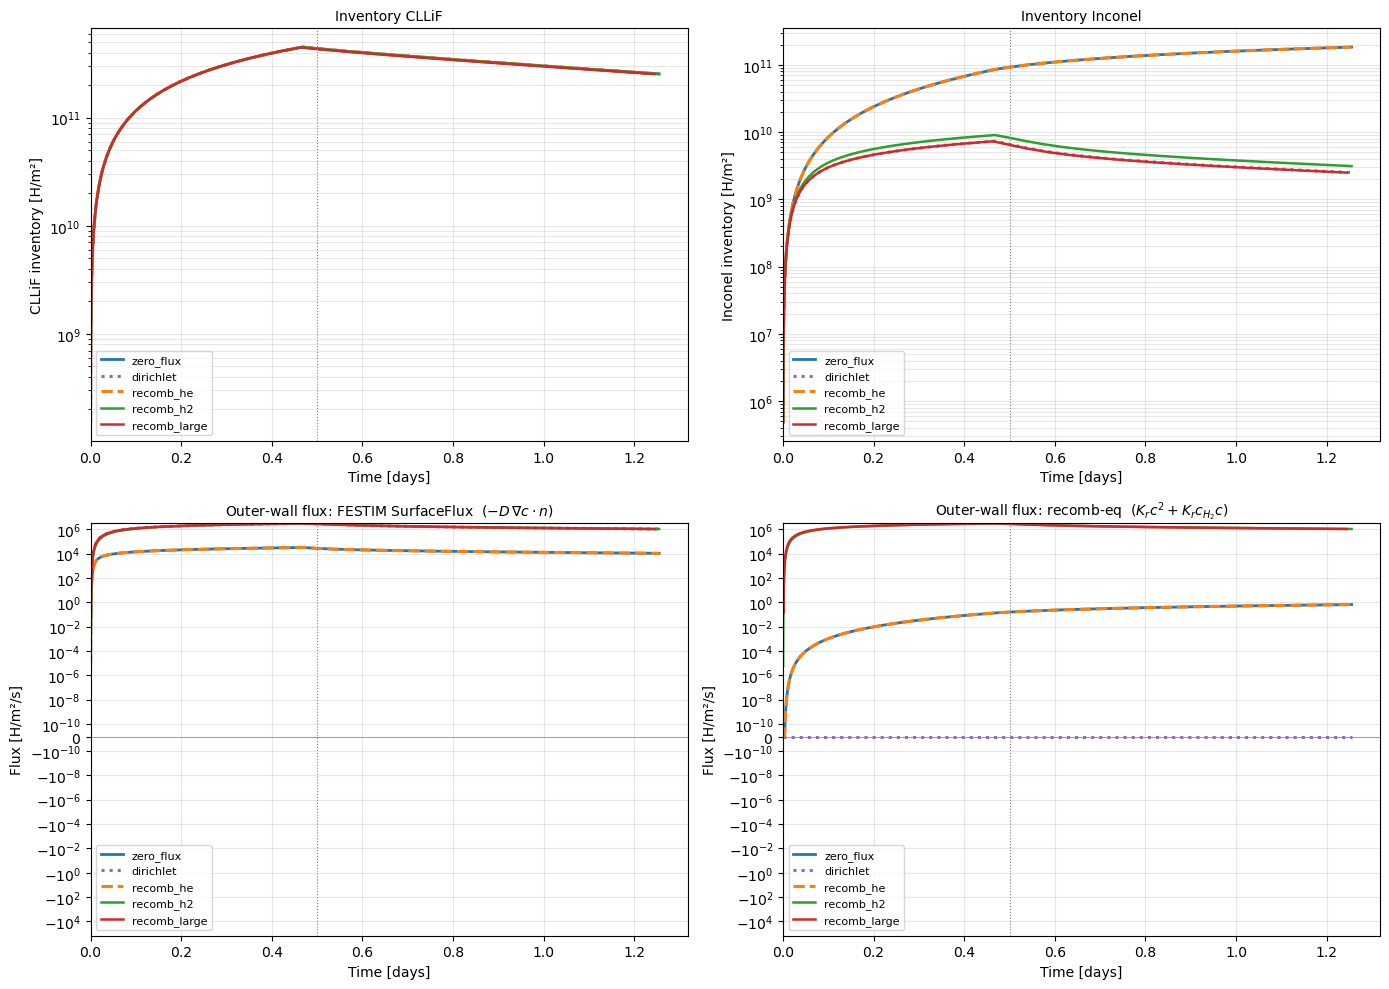

Plot saved to results_1d/comparison.png


In [8]:

# ---------------------------------------------------------------------------
# Plot: 4 panels — inventories + two flux versions side by side
# ---------------------------------------------------------------------------
s_to_day = 1 / 3600 / 24
t_irr_day = irradiation_time * s_to_day

case_styles = {
    "zero_flux": dict(color="C0", linestyle="-", linewidth=2.0),
    "recomb_he": dict(color="C1", linestyle="--", linewidth=2.2),
    "recomb_h2": dict(color="C2", linestyle="-", linewidth=1.8),
    "recomb_large": dict(color="C3", linestyle="-", linewidth=1.8),
    "dirichlet": dict(color="C4", linestyle=":", linewidth=2.2),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

panels = [
    dict(
        ax=axes[0, 0],
        title="Inventory CLLiF",
        file="inventory_cllif.csv",
        ylabel="CLLiF inventory [H/m²]",
        scale="log",
    ),
    dict(
        ax=axes[0, 1],
        title="Inventory Inconel",
        file="inventory_inconel.csv",
        ylabel="Inconel inventory [H/m²]",
        scale="log",
    ),
    dict(
        ax=axes[1, 0],
        title="Outer-wall flux: FESTIM SurfaceFlux  ($-D\\,\\nabla c\\cdot n$)",
        file="flux_outer_wall.csv",
        ylabel="Flux [H/m²/s]",
        scale="symlog",
    ),
    dict(
        ax=axes[1, 1],
        title=r"Outer-wall flux: recomb-eq  ($K_r c^2 + K_r c_{H_2} c$)",
        file="flux_outer_wall_recomb_eq.csv",
        ylabel="Flux [H/m²/s]",
        scale="symlog",
    ),
]

for panel in panels:
    ax = panel["ax"]
    for case in cases:
        fpath = f"results_1d/{case}/{panel['file']}"
        if not os.path.exists(fpath):
            continue
        df = pd.read_csv(fpath)
        t = df.iloc[:, 0].values * s_to_day
        y = df.iloc[:, 1].values
        ax.plot(t, y, label=case, **case_styles[case])

    ax.axvline(t_irr_day, color="0.5", linewidth=0.8, linestyle=":")
    # ax.text(
    #     t_irr_day,
    #     1.02,
    #     "irradiation end",
    #     transform=ax.get_xaxis_transform(),
    #     ha="center",
    #     va="bottom",
    #     fontsize=8,
    #     color="0.4",
    # )

    ax.set_xlabel("Time [days]")
    ax.set_ylabel(panel["ylabel"])
    ax.set_title(panel["title"], fontsize=10)
    ax.set_xlim(left=0)

    if panel["scale"] == "log":
        ax.set_yscale("log")
    elif panel["scale"] == "symlog":
        ax.set_yscale("symlog", linthresh=1e-10)
        ax.axhline(0, color="0.5", linewidth=0.5)

    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results_1d/comparison.png", dpi=150)
plt.show()
print("Plot saved to results_1d/comparison.png")
